# Phase 2 — Static Fuzzy Baseline

Dự án: **An Evolving Fuzzy Reasoning System for Sensor Stream Anomaly Detection under Concept Drift**

## Mục tiêu Phase 2:
Xây dựng hệ suy luận mờ tĩnh (**Static Fuzzy Baseline**) làm chuẩn đối chứng trước khi tích hợp các cơ chế tự tiến hóa (evolving) và phát hiện trôi dạt khái niệm (concept drift detection).

Các bước thực hiện trong Phase 2:
- **2.1**: Thiết kế FIS (Mamdani, Anomaly Score $\in [0, 1]$, centroid) - *Đã chốt ở docs/phase-02.1-fuzzy-reasoning-target.md*
- **2.2**: Phân tích phân phối Train (Train Distribution Analysis) $\rightarrow$ Xác định các mốc Membership Functions (MF)
- **2.3**: Xây dựng Membership Functions (5 inputs + 1 output)
- **2.4**: Thiết kế Fuzzy Rule Base (~10–20 rules)
- **2.5**: Xây dựng Mamdani FIS hoàn chỉnh
- **2.6**: Kiểm thử FIS (Test mẫu & trực quan hóa suy luận)
- **2.7**: Chốt Static Baseline & đóng băng sẵn sàng sang Phase 3

---
## Phase 2.2 — Phân tích phân phối Train để xác định Membership Functions

Nguyên tắc quan trọng:
- Toàn bộ tri thức và các mốc hàm thuộc tính (MF) được thiết kế **dựa trên 6.000 mẫu Train** (UDI: 1 $\rightarrow$ 6.000).
- Tuyệt đối không sử dụng nhãn `Machine failure` hoặc dữ liệu Validation/Test để dò/tối ưu MF ở bước này.


### Phase 2.2.1 — Chuẩn bị dữ liệu Train và Thống kê mô tả

In [1]:
# Phase 2.2.1 — Prepare training data
from pathlib import Path
import pandas as pd
import numpy as np

# Load dữ liệu (hỗ trợ cả khi chạy từ notebook dir hoặc project root)
data_path = Path("../data/ai4i2020.csv") if Path("../data/ai4i2020.csv").exists() else Path("data/ai4i2020.csv")
df = pd.read_csv(data_path)

sensor_cols = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

train_df = df.iloc[:6000].copy()

print("Train shape:", train_df.shape)
print("UDI range:", train_df["UDI"].min(), "→", train_df["UDI"].max())

display(train_df[sensor_cols].describe().T)


Train shape: (6000, 14)
UDI range: 1 → 6000


,count,mean,std,min,25%,50%,75%,max
Air temperature [K],6000.0,300.321550,2.283496,295.3,298.300,300.4,302.3,304.5
Process temperature [K],6000.0,309.922000,1.665028,305.7,308.600,309.7,311.1,313.8
Rotational speed [rpm],6000.0,1539.999667,182.909386,1168.0,1422.000,1504.0,1612.0,2886.0
Torque [Nm],6000.0,39.954950,9.977035,3.8,33.275,40.0,46.8,76.2
Tool wear [min],6000.0,108.960000,63.976469,0.0,54.000,109.0,164.0,253.0


### Phase 2.2.2 — Phân tích phân phối chi tiết qua các phân vị (Quantiles)

In [2]:
# Phase 2.2.2 — Detailed distribution statistics

quantiles = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]

distribution_stats = train_df[sensor_cols].quantile(quantiles).T

display(distribution_stats)


,0.01,0.05,0.10,0.25,0.50,0.75,0.90,0.95,0.99
Air temperature [K],295.600,296.8,297.40,298.300,300.4,302.3,303.4,303.7,304.20
Process temperature [K],306.200,307.5,307.80,308.600,309.7,311.1,312.3,312.8,313.40
Rotational speed [rpm],1278.000,1331.0,1363.90,1422.000,1504.0,1612.0,1748.0,1877.0,2206.05
Torque [Nm],16.499,23.3,27.19,33.275,40.0,46.8,52.5,55.8,62.80
Tool wear [min],0.000,10.0,20.00,54.000,109.0,164.0,197.0,208.0,225.00


### Phase 2.2.3 — Trực quan hóa phân phối 5 biến cảm biến trên Train Set

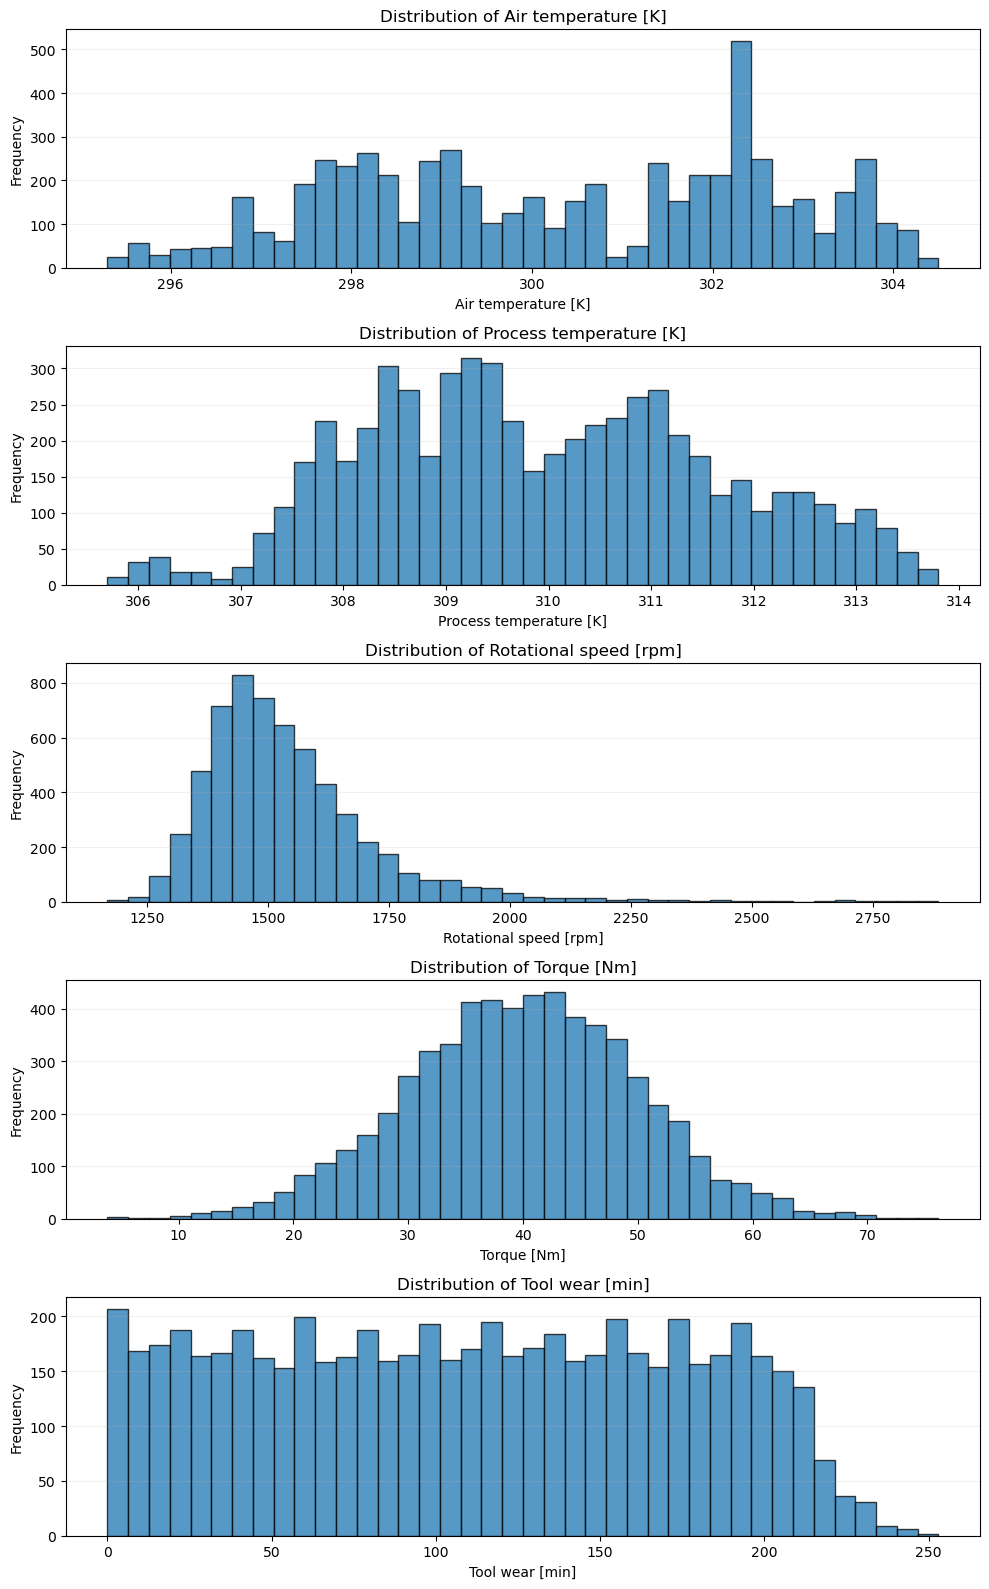

In [3]:
# Phase 2.2.3 — Visualize sensor distributions
import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(sensor_cols), 1, figsize=(10, 16))

for ax, col in zip(axes, sensor_cols):
    ax.hist(
        train_df[col],
        bins=40,
        edgecolor="black",
        alpha=0.75
    )
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
    ax.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()


---
## Phase 2.3 — Xây dựng Membership Functions (5 inputs + 1 output)

### Phase 2.3.1 — Kiểm tra thư viện scikit-fuzzy

In [4]:
# Phase 2.3.1 — Check scikit-fuzzy
import skfuzzy as fuzz

print("scikit-fuzzy:", fuzz.__version__)

scikit-fuzzy: 0.5.0
